# Neural Networks — An Illustrated Tour

> A stack of differentiable layers trained end-to-end. Replace the perceptron's hard threshold with smooth activations and gradient descent does the rest — yielding a **universal function approximator**.

---

**What we cover:**
- Network architecture: layers, weights, biases
- Forward pass — how a prediction is computed
- Activation functions — why non-linearity is essential
- Backpropagation — the chain rule running backwards
- Training on XOR — a problem no linear model can solve
- Universal approximation — one hidden layer is (theoretically) enough

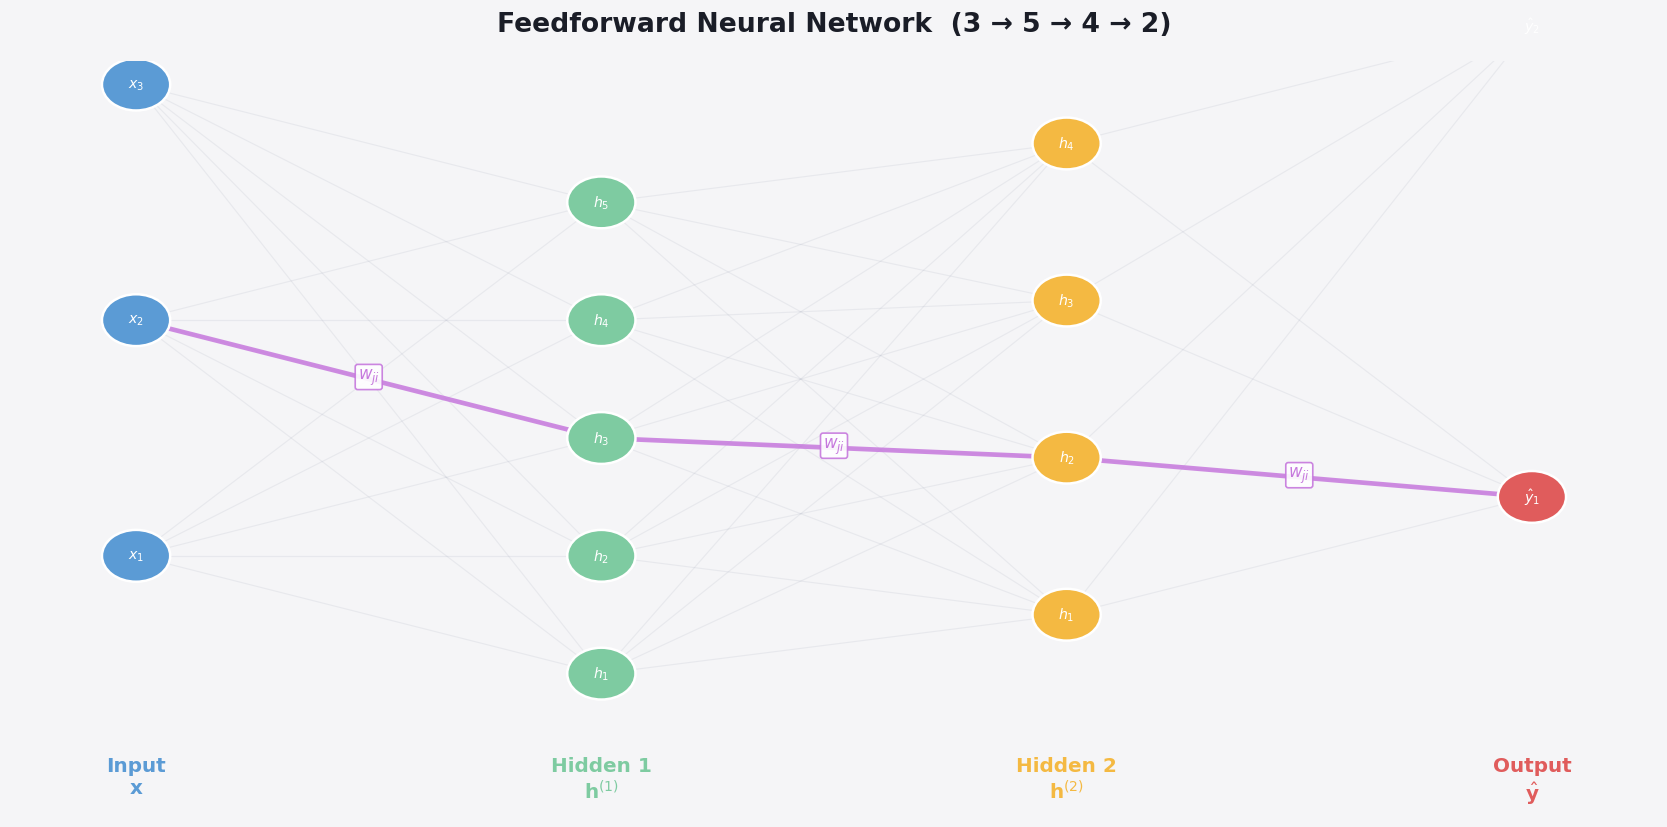

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CG='#888fa5'; CP='#c678dd'

# ── architecture: 3 → 5 → 4 → 2 ─────────────────────────────────────────────
layers      = [3, 5, 4, 2]
layer_names = ['Input\n$\\mathbf{x}$', 'Hidden 1\n$\\mathbf{h}^{(1)}$',
               'Hidden 2\n$\\mathbf{h}^{(2)}$', 'Output\n$\\hat{\\mathbf{y}}$']
layer_cols  = [C0, CM, CB, C1]
max_n = max(layers); x_gap = 3.0; r = 0.22

def node_pos(layers, x_gap):
    pos = []
    for l, n in enumerate(layers):
        ys = np.linspace(0, (max_n - 1) * 1.0, n) + (max_n - n) / 2.0
        pos.append([(l * x_gap, float(y)) for y in ys])
    return pos

pos = node_pos(layers, x_gap)

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(-0.8, (len(layers)-1)*x_gap+0.8); ax.set_ylim(-1.2, max_n+0.2); ax.axis('off')

# All connections (dim)
for l in range(len(layers)-1):
    for (x1, y1) in pos[l]:
        for (x2, y2) in pos[l+1]:
            ax.plot([x1,x2],[y1,y2], color=CG, alpha=0.12, lw=0.7, zorder=1)

# Highlighted path
path_idx = [1, 2, 1, 0]
for l in range(len(layers)-1):
    x1, y1 = pos[l][path_idx[l]]
    x2, y2 = pos[l+1][path_idx[l+1]]
    ax.plot([x1,x2],[y1,y2], color=CP, alpha=0.85, lw=2.8, zorder=2)
    xm, ym = (x1+x2)/2, (y1+y2)/2
    ax.annotate('$w_{ji}$', xy=(xm, ym), fontsize=10, color=CP, ha='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=CP, alpha=0.9), zorder=6)

# Nodes
node_labels = [
    ['$x_1$','$x_2$','$x_3$'],
    ['$h_1$','$h_2$','$h_3$','$h_4$','$h_5$'],
    ['$h_1$','$h_2$','$h_3$','$h_4$'],
    ['$\\hat{y}_1$','$\\hat{y}_2$'],
]
for l, (plist, name, col, nlabs) in enumerate(zip(pos, layer_names, layer_cols, node_labels)):
    for k, (x, y) in enumerate(plist):
        ax.add_patch(Circle((x, y), r, color=col, ec='white', lw=1.5, zorder=4))
        ax.text(x, y, nlabs[k], ha='center', va='center', fontsize=8.5,
                color='white', fontweight='bold', zorder=5)
    ax.text(plist[0][0], -0.7, name, ha='center', va='top',
            fontsize=12, fontweight='bold', color=col)

ax.set_title('Feedforward Neural Network  (3 → 5 → 4 → 2)',
             fontsize=16, fontweight='bold', pad=18)
plt.tight_layout(); plt.show()


---
## The Forward Pass

Each layer applies a **linear transformation** followed by an **element-wise non-linearity**:

$$\mathbf{z}^{(\ell)} = W^{(\ell)}\,\mathbf{a}^{(\ell-1)} + \mathbf{b}^{(\ell)}, \qquad
  \mathbf{a}^{(\ell)} = \sigma\!\left(\mathbf{z}^{(\ell)}\right)$$

where $W^{(\ell)} \in \mathbb{R}^{n_\ell \times n_{\ell-1}}$ and $\mathbf{b}^{(\ell)} \in \mathbb{R}^{n_\ell}$.

| Symbol | Meaning |
|---|---|
| $\mathbf{x} = \mathbf{a}^{(0)}$ | Input features |
| $W^{(\ell)},\, \mathbf{b}^{(\ell)}$ | Weights and biases of layer $\ell$ |
| $\mathbf{z}^{(\ell)}$ | Pre-activation (linear combination) |
| $\sigma(\cdot)$ | Activation function (element-wise non-linearity) |
| $\hat{\mathbf{y}} = \mathbf{a}^{(L)}$ | Final prediction |

**Why the non-linearity?**  Without $\sigma$, composing linear layers gives another linear transformation — depth buys nothing.  Non-linear activations let the network carve curved, non-convex decision boundaries.

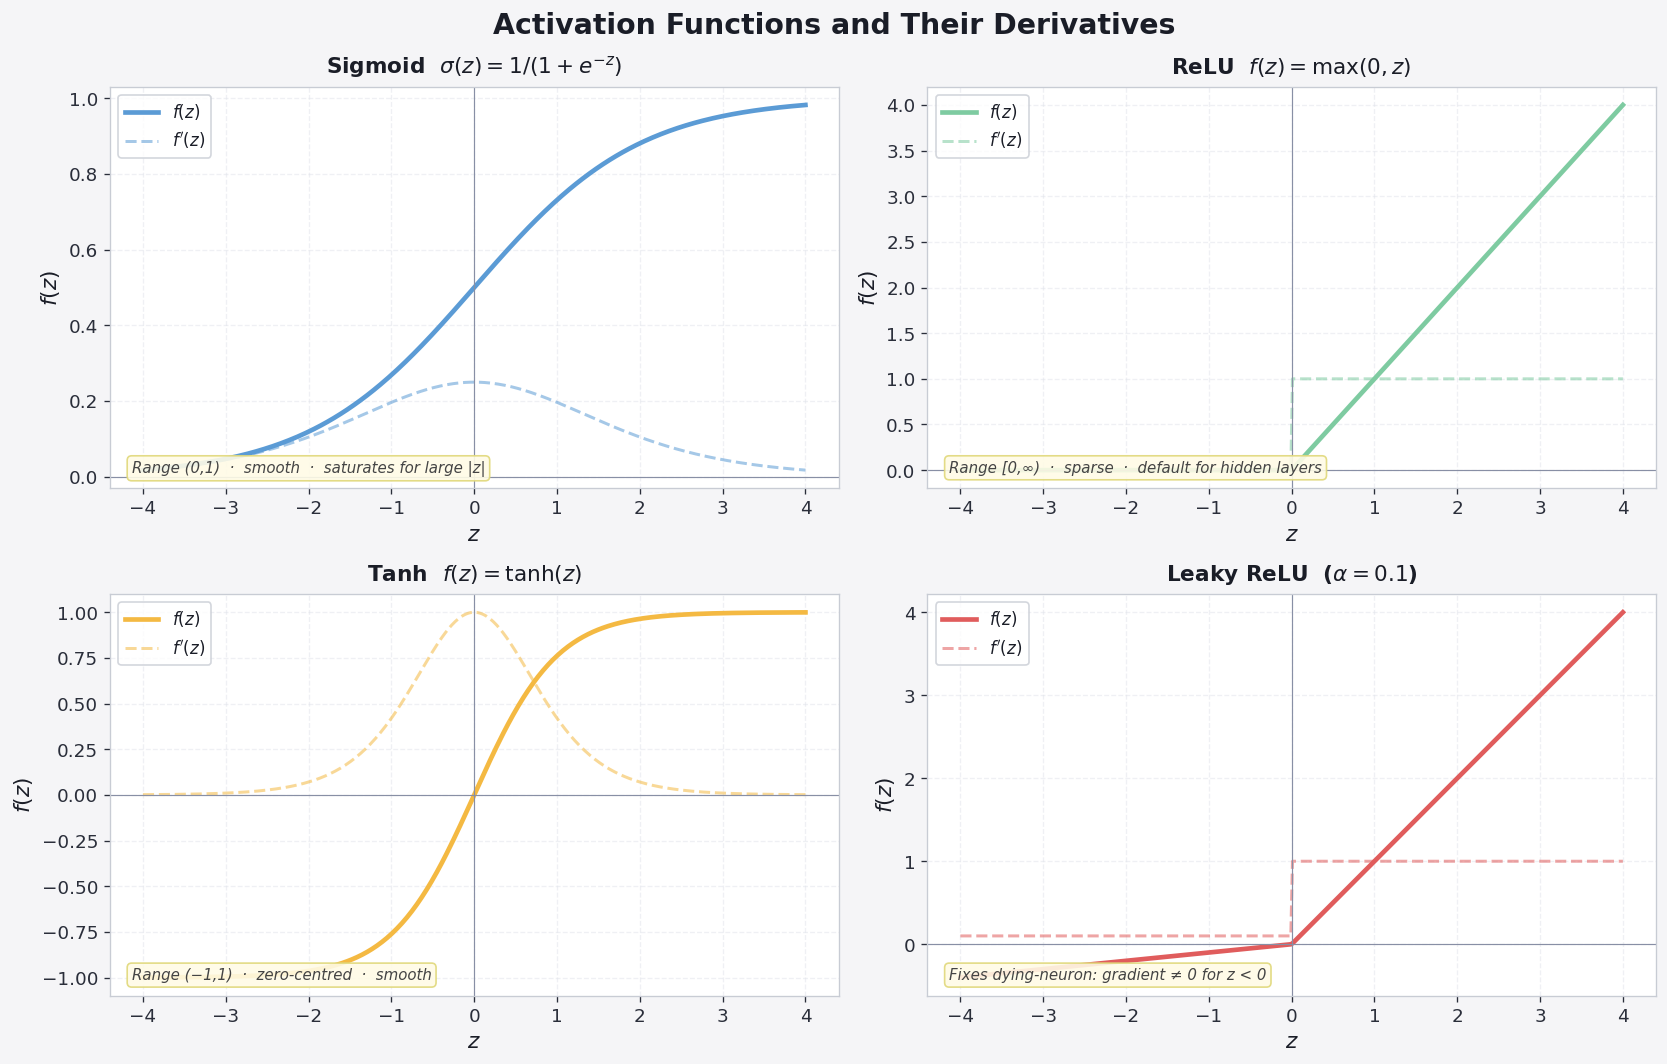

In [2]:
x = np.linspace(-4, 4, 400)

def sigmoid(z):      return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def d_sigmoid(z):    s = sigmoid(z); return s * (1 - s)
def relu(z):         return np.maximum(0, z)
def d_relu(z):       return (z > 0).astype(float)
def tanh_(z):        return np.tanh(z)
def d_tanh(z):       return 1 - np.tanh(z)**2
def leaky_relu(z):   return np.where(z >= 0, z, 0.1 * z)
def d_leaky_relu(z): return np.where(z >= 0, 1.0, 0.1)

acts = [
    ('Sigmoid  $\\sigma(z)=1/(1+e^{-z})$',  sigmoid,     d_sigmoid,     C0,
     'Range (0,1)  ·  smooth  ·  saturates for large |z|'),
    ('ReLU  $f(z)=\\max(0,z)$',              relu,        d_relu,        CM,
     'Range [0,∞)  ·  sparse  ·  default for hidden layers'),
    ('Tanh  $f(z)=\\tanh(z)$',               tanh_,       d_tanh,        CB,
     'Range (−1,1)  ·  zero-centred  ·  smooth'),
    ('Leaky ReLU  ($\\alpha=0.1$)',           leaky_relu,  d_leaky_relu,  C1,
     'Fixes dying-neuron: gradient ≠ 0 for z < 0'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (title, f, df, color, note) in zip(axes.flat, acts):
    ax.plot(x, f(x),  color=color, lw=2.8, label='$f(z)$')
    ax.plot(x, df(x), color=color, lw=1.8, ls='--', alpha=0.55, label="$f'(z)$")
    ax.axhline(0, color=CG, lw=0.7); ax.axvline(0, color=CG, lw=0.7)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('$z$'); ax.set_ylabel('$f(z)$')
    ax.legend(fontsize=10); ax.grid(True)
    ax.text(0.03, 0.04, note, transform=ax.transAxes, fontsize=9, color='#444',
            style='italic', bbox=dict(boxstyle='round,pad=0.3', fc='#fffbe6', ec='#e0d87a', alpha=0.9))

fig.suptitle('Activation Functions and Their Derivatives', fontsize=17, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Backpropagation — the Chain Rule Running Backwards

The loss $\mathcal{L}$ depends on $W^{(\ell)}$ only through the intermediate activations. Applying the chain rule layer by layer gives the **error signal**:

$$\boldsymbol{\delta}^{(\ell)} =
  \bigl(W^{(\ell+1)}\bigr)^{\!\top}\boldsymbol{\delta}^{(\ell+1)}
  \odot \sigma'\!\left(\mathbf{z}^{(\ell)}\right)$$

and the weight gradient:

$$\frac{\partial \mathcal{L}}{\partial W^{(\ell)}} =
  \frac{1}{m}\sum_{i=1}^{m}
  \boldsymbol{\delta}^{(\ell)(i)}\left(\mathbf{a}^{(\ell-1)(i)}\right)^{\!\top}$$

The update rule is then $W^{(\ell)} \leftarrow W^{(\ell)} - \alpha\,\partial\mathcal{L}/\partial W^{(\ell)}$.

**Nice simplification for binary cross-entropy + sigmoid output:**
$$\boldsymbol{\delta}^{(L)} = \hat{\mathbf{y}} - \mathbf{y}$$
identical in form to logistic regression — the non-linearity cancels the loss derivative.

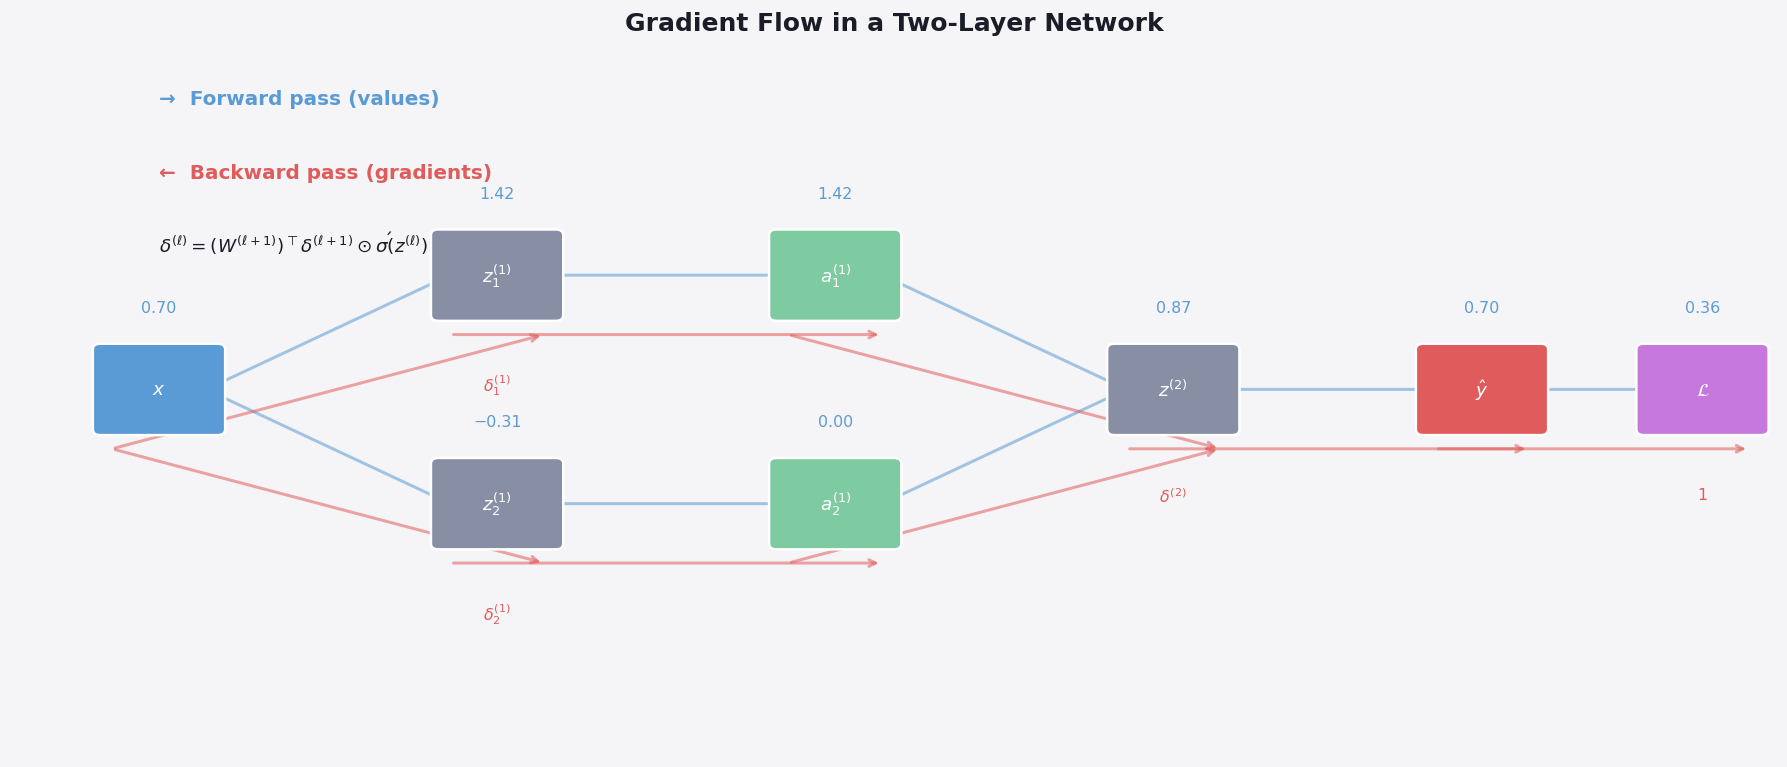

In [3]:
fig, ax = plt.subplots(figsize=(15, 6.5))
ax.set_xlim(-0.5, 11.5); ax.set_ylim(-1.2, 5); ax.axis('off')

nodes = [
    # (label, x, y, col, fwd_val, bwd_val)
    ('$x$',             0.5,  2,   C0,   '0.70',  '—'),
    ('$z^{(1)}_1$',     2.8,  3.0, CG,   '1.42',  '$\\delta^{(1)}_1$'),
    ('$z^{(1)}_2$',     2.8,  1.0, CG,   '−0.31', '$\\delta^{(1)}_2$'),
    ('$a^{(1)}_1$',     5.1,  3.0, CM,   '1.42',  '—'),
    ('$a^{(1)}_2$',     5.1,  1.0, CM,   '0.00',  '—'),
    ('$z^{(2)}$',       7.4,  2.0, CG,   '0.87',  '$\\delta^{(2)}$'),
    ('$\\hat{y}$',      9.5,  2.0, C1,   '0.70',  '—'),
    ('$\\mathcal{L}$', 11.0,  2.0, CP,   '0.36',  '1'),
]

fwd_edges = [(0,1),(0,2),(1,3),(2,4),(3,5),(4,5),(5,6),(6,7)]
for (i,j) in fwd_edges:
    x1, y1 = nodes[i][1], nodes[i][2]
    x2, y2 = nodes[j][1], nodes[j][2]
    ax.annotate('', xy=(x2-0.32, y2), xytext=(x1+0.32, y1),
                arrowprops=dict(arrowstyle='->', color=C0, lw=1.8, alpha=0.55))
for (i,j) in reversed(fwd_edges):
    x1, y1 = nodes[i][1], nodes[i][2]-0.52
    x2, y2 = nodes[j][1], nodes[j][2]-0.52
    ax.annotate('', xy=(x2+0.32, y2), xytext=(x1-0.32, y1),
                arrowprops=dict(arrowstyle='->', color=C1, lw=1.8, alpha=0.55))

for label, x, y, col, fv, bv in nodes:
    ax.add_patch(FancyBboxPatch((x-0.4, y-0.35), 0.8, 0.7,
                                boxstyle='round,pad=0.05', fc=col, ec='white', lw=1.5, zorder=3))
    ax.text(x, y, label, ha='center', va='center', fontsize=11,
            color='white', fontweight='bold', zorder=4)
    ax.text(x, y+0.65, fv, ha='center', va='bottom', fontsize=9.5, color=C0)
    if bv != '—':
        ax.text(x, y-0.85, bv, ha='center', va='top', fontsize=9.5, color=C1)

ax.text(0.5, 4.5, '→  Forward pass (values)', color=C0, fontsize=12, fontweight='bold')
ax.text(0.5, 3.85, '←  Backward pass (gradients)', color=C1, fontsize=12, fontweight='bold')
ax.text(0.5, 3.2,
        r'$\delta^{(\ell)} = (W^{(\ell+1)})^\top \delta^{(\ell+1)} \odot \sigma\'(z^{(\ell)})$',
        color='#1a1d27', fontsize=11)
ax.set_title('Gradient Flow in a Two-Layer Network', fontsize=15, fontweight='bold', pad=10)
plt.tight_layout(); plt.show()


---
## XOR — Why Non-Linearity Is Non-Negotiable

XOR outputs 1 iff **exactly one** input is 1.  The two positive corners $\{(0,1),(1,0)\}$ and two negative corners $\{(0,0),(1,1)\}$ are arranged diagonally — no single hyperplane separates them.

| $x_1$ | $x_2$ | $y = x_1 \oplus x_2$ |
|:---:|:---:|:---:|
| 0 | 0 | **0** |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | **0** |

A logistic regression achieves only **50 % accuracy** on XOR — no better than chance.  A two-layer neural network solves it exactly.

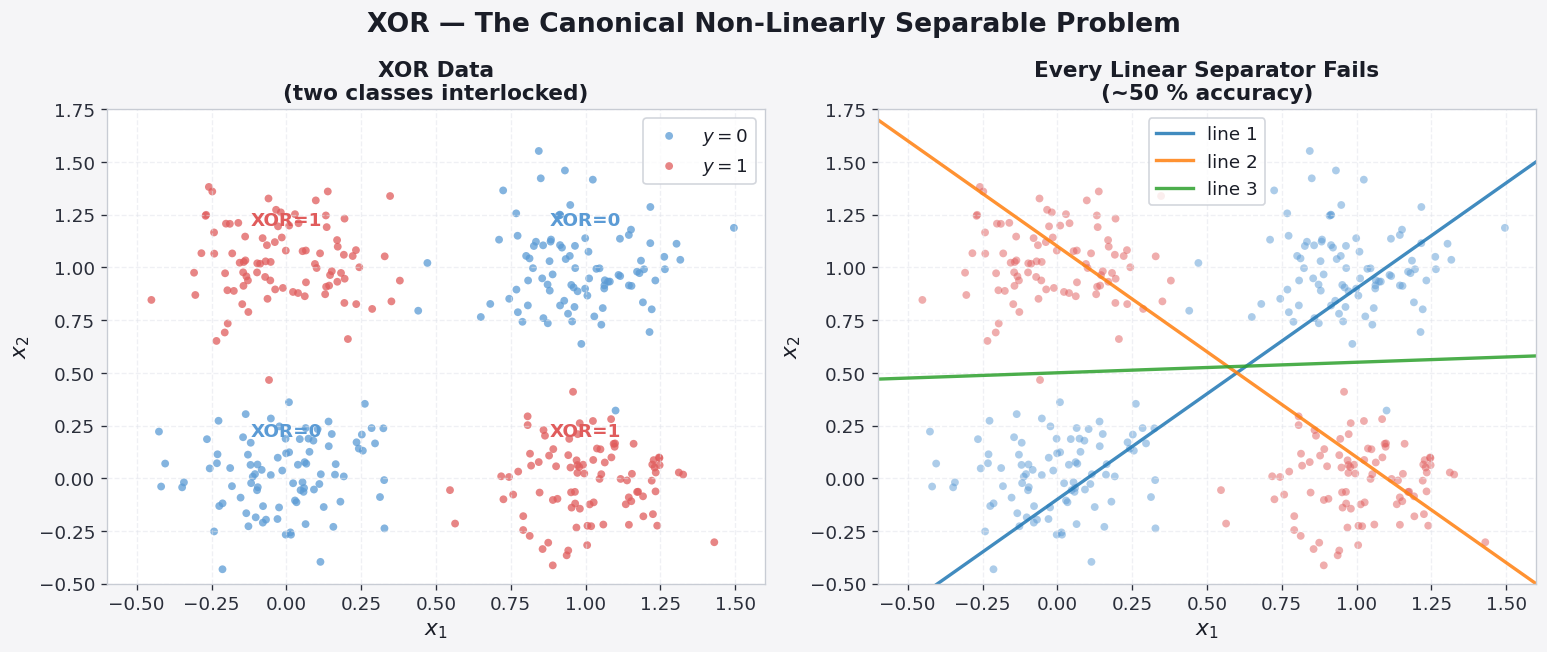

In [4]:
rng = np.random.default_rng(0)
n = 90

X_xor = np.vstack([
    rng.normal([0,0], 0.18, (n,2)),   # y=0
    rng.normal([1,1], 0.18, (n,2)),   # y=0
    rng.normal([0,1], 0.18, (n,2)),   # y=1
    rng.normal([1,0], 0.18, (n,2)),   # y=1
])
y_xor = np.array([0]*n*2 + [1]*n*2, dtype=float)
idx   = rng.permutation(len(y_xor))
X_xor, y_xor = X_xor[idx], y_xor[idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.scatter(X_xor[y_xor==0,0], X_xor[y_xor==0,1], c=C0, s=22, alpha=0.75, edgecolors='none', label='$y=0$')
ax.scatter(X_xor[y_xor==1,0], X_xor[y_xor==1,1], c=C1, s=22, alpha=0.75, edgecolors='none', label='$y=1$')
for (xi,yi) in [([0,0],0),([1,1],0),([0,1],1),([1,0],1)]:
    ax.text(xi[0], xi[1]+0.2, f'XOR={yi}', ha='center', fontsize=11,
            color=C0 if yi==0 else C1, fontweight='bold')
ax.set_xlim(-0.6,1.6); ax.set_ylim(-0.5,1.75)
ax.set_title('XOR Data\n(two classes interlocked)', fontsize=13, fontweight='bold')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(); ax.grid(True)

ax2 = axes[1]
ax2.scatter(X_xor[y_xor==0,0], X_xor[y_xor==0,1], c=C0, s=22, alpha=0.50, edgecolors='none')
ax2.scatter(X_xor[y_xor==1,0], X_xor[y_xor==1,1], c=C1, s=22, alpha=0.50, edgecolors='none')
xx_line = np.linspace(-0.6, 1.6, 200)
for slope, intercept, label in [(1.0,-0.1,'line 1'),(-1.0,1.1,'line 2'),(0.05,0.5,'line 3')]:
    ax2.plot(xx_line, slope*xx_line+intercept, lw=2.0, alpha=0.85, label=label)
ax2.set_xlim(-0.6,1.6); ax2.set_ylim(-0.5,1.75)
ax2.set_title('Every Linear Separator Fails\n(~50 % accuracy)', fontsize=13, fontweight='bold')
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$'); ax2.legend(); ax2.grid(True)

fig.suptitle('XOR — The Canonical Non-Linearly Separable Problem', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


In [5]:
class NeuralNet:
    # feedforward net with ReLU hidden layers and sigmoid output
    def __init__(self, sizes, lr=0.08, seed=42):
        rng = np.random.default_rng(seed)
        self.lr = lr; self.sizes = sizes
        self.W = []; self.b = []
        for i in range(len(sizes)-1):
            self.W.append(rng.normal(0, np.sqrt(2/sizes[i]), (sizes[i+1], sizes[i])))
            self.b.append(np.zeros((sizes[i+1], 1)))

    @staticmethod
    def _relu(z):    return np.maximum(0, z)
    @staticmethod
    def _sig(z):     return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        A = X.T; self._As = [A]; self._Zs = []
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = W @ A + b; self._Zs.append(Z)
            A = self._relu(Z) if i < len(self.W)-1 else self._sig(Z)
            self._As.append(A)
        return A

    def loss(self, y):
        a = self._As[-1]; y = y.reshape(1,-1); e = 1e-9
        return float(-np.mean(y*np.log(a+e) + (1-y)*np.log(1-a+e)))

    def backward(self, y):
        m = len(y); y = y.reshape(1,-1)
        dZ = self._As[-1] - y        # BCE + sigmoid simplifies nicely
        for i in reversed(range(len(self.W))):
            dW = dZ @ self._As[i].T / m
            db = np.mean(dZ, axis=1, keepdims=True)
            if i > 0:
                dZ = (self.W[i].T @ dZ) * (self._Zs[i-1] > 0)
            self.W[i] -= self.lr * dW
            self.b[i] -= self.lr * db

    def predict_grid(self, grid, shape):
        A = grid.T
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = W @ A + b
            A = self._relu(Z) if i < len(self.W)-1 else self._sig(Z)
        return A.reshape(shape)

# ── mesh grid for boundary plots ──────────────────────────────────────────────
xx, yy   = np.meshgrid(np.linspace(-0.6,1.6,200), np.linspace(-0.5,1.6,200))
grid_2d  = np.c_[xx.ravel(), yy.ravel()]
print('NeuralNet ready.')


NeuralNet ready.


Final loss: 0.0178   accuracy: 99.4%


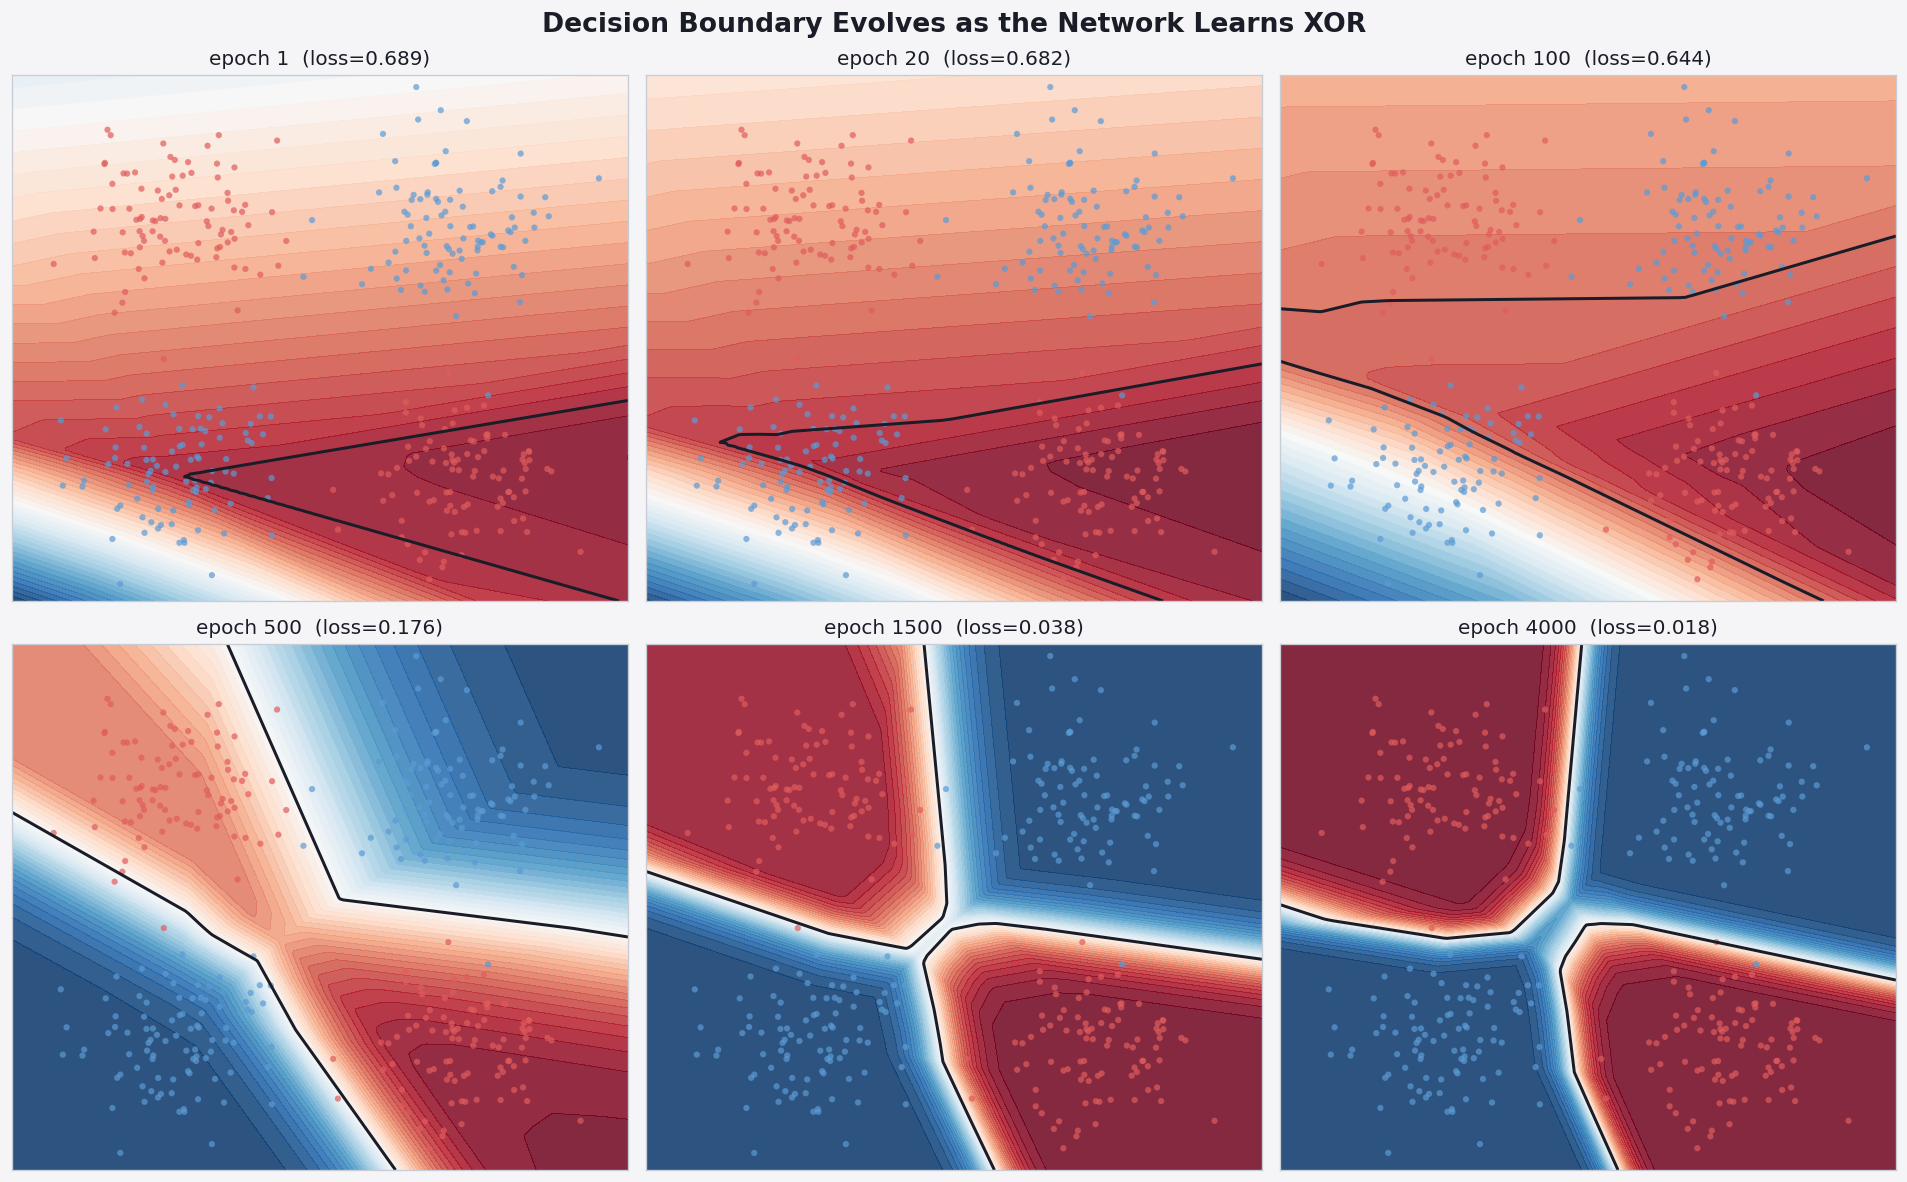

In [6]:
snap_at    = [1, 20, 100, 500, 1500, 4000]
net        = NeuralNet([2,8,8,1], lr=0.08, seed=7)
losses     = []; boundaries = {}

for epoch in range(1, 4001):
    net.forward(X_xor)
    losses.append(net.loss(y_xor))
    if epoch in snap_at:
        boundaries[epoch] = net.predict_grid(grid_2d, xx.shape).copy()
    net.backward(y_xor)

net.forward(X_xor)
final_acc = float(np.mean((net._As[-1].flatten()>0.5) == y_xor.astype(bool)))
print(f'Final loss: {losses[-1]:.4f}   accuracy: {final_acc:.1%}')

fig, axes = plt.subplots(2, 3, figsize=(16,10))
for ax, ep in zip(axes.flat, snap_at):
    Z = boundaries[ep]
    ax.contourf(xx, yy, Z, levels=40, cmap='RdBu_r', alpha=0.85)
    ax.contour( xx, yy, Z, levels=[0.5], colors='#1a1d27', linewidths=1.8)
    ax.scatter(X_xor[y_xor==0,0], X_xor[y_xor==0,1], c=C0, s=14, alpha=0.7, edgecolors='none')
    ax.scatter(X_xor[y_xor==1,0], X_xor[y_xor==1,1], c=C1, s=14, alpha=0.7, edgecolors='none')
    ax.set_xlim(-0.6,1.6); ax.set_ylim(-0.5,1.6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'epoch {ep}  (loss={losses[ep-1]:.3f})', fontsize=12)

fig.suptitle('Decision Boundary Evolves as the Network Learns XOR',
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


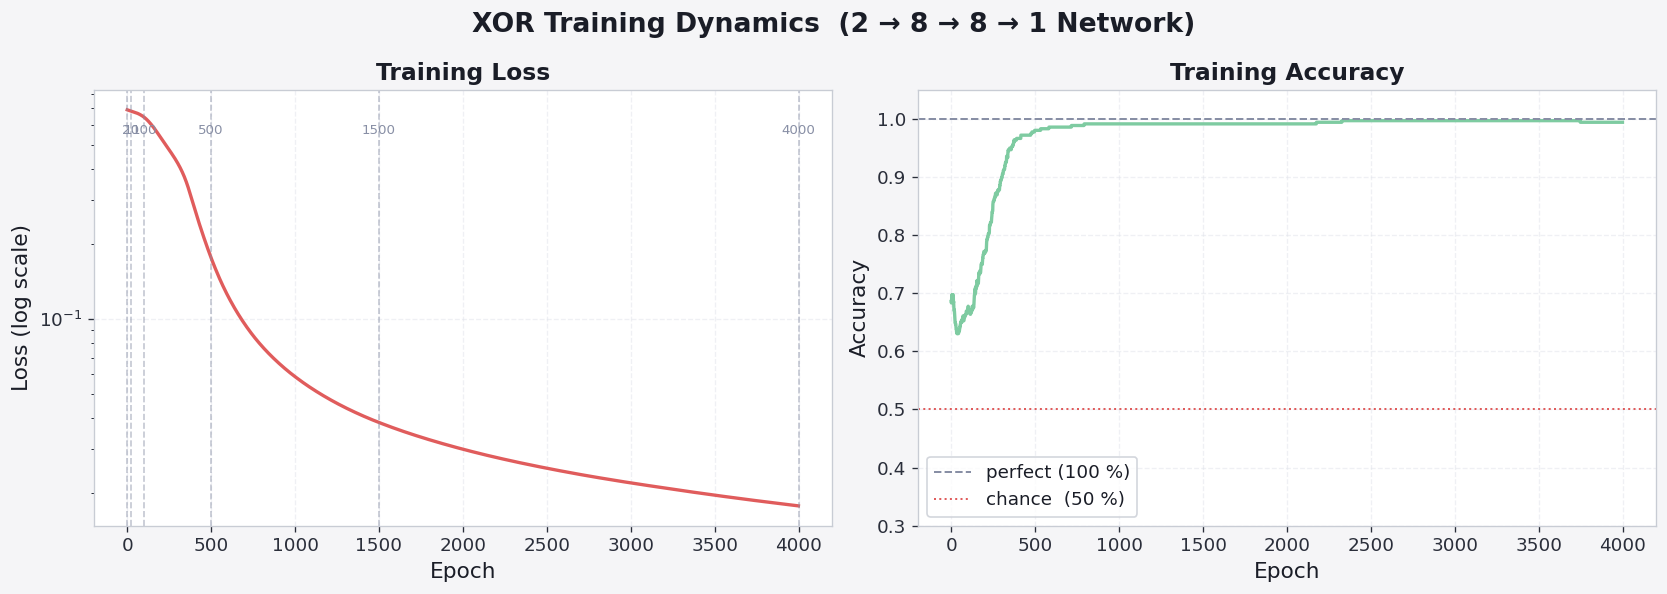

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(losses, color=C1, lw=2.0)
for ep in snap_at:
    ax.axvline(ep, color=CG, lw=1.0, ls='--', alpha=0.5)
    ax.text(ep, losses[0]*0.8, str(ep), ha='center', fontsize=8, color=CG)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (log scale)')
ax.set_title('Training Loss', fontsize=14, fontweight='bold'); ax.grid(True)

# re-run to collect accuracy
net2   = NeuralNet([2,8,8,1], lr=0.08, seed=7)
acc_h  = []
for epoch in range(1, 4001):
    preds = net2.forward(X_xor).flatten() > 0.5
    acc_h.append(float(np.mean(preds == y_xor.astype(bool))))
    net2.backward(y_xor)

ax2 = axes[1]
ax2.plot(acc_h, color=CM, lw=2.0)
ax2.axhline(1.0, color=CG,  lw=1.2, ls='--', label='perfect (100 %)')
ax2.axhline(0.5, color=C1,  lw=1.2, ls=':',  label='chance  (50 %)')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim(0.3, 1.05); ax2.legend(); ax2.grid(True)

fig.suptitle('XOR Training Dynamics  (2 → 8 → 8 → 1 Network)',
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


---
## Universal Approximation Theorem

> **Theorem (Cybenko 1989; Hornik 1991):** A feedforward network with a **single hidden layer** of sufficiently many neurons can approximate any continuous function on a compact subset of $\mathbb{R}^n$ to arbitrary precision.

Neural networks are therefore, in principle, as expressive as you wish.  In practice:
- **More hidden units** → better approximation, but more data and compute
- **Deeper networks** learn hierarchical features more efficiently than wide shallow ones — ReLU networks partition the input space into linear regions, and the count of regions grows *exponentially* with depth
- The theorem guarantees **existence**, not learnability — gradient descent may not find the optimal weights

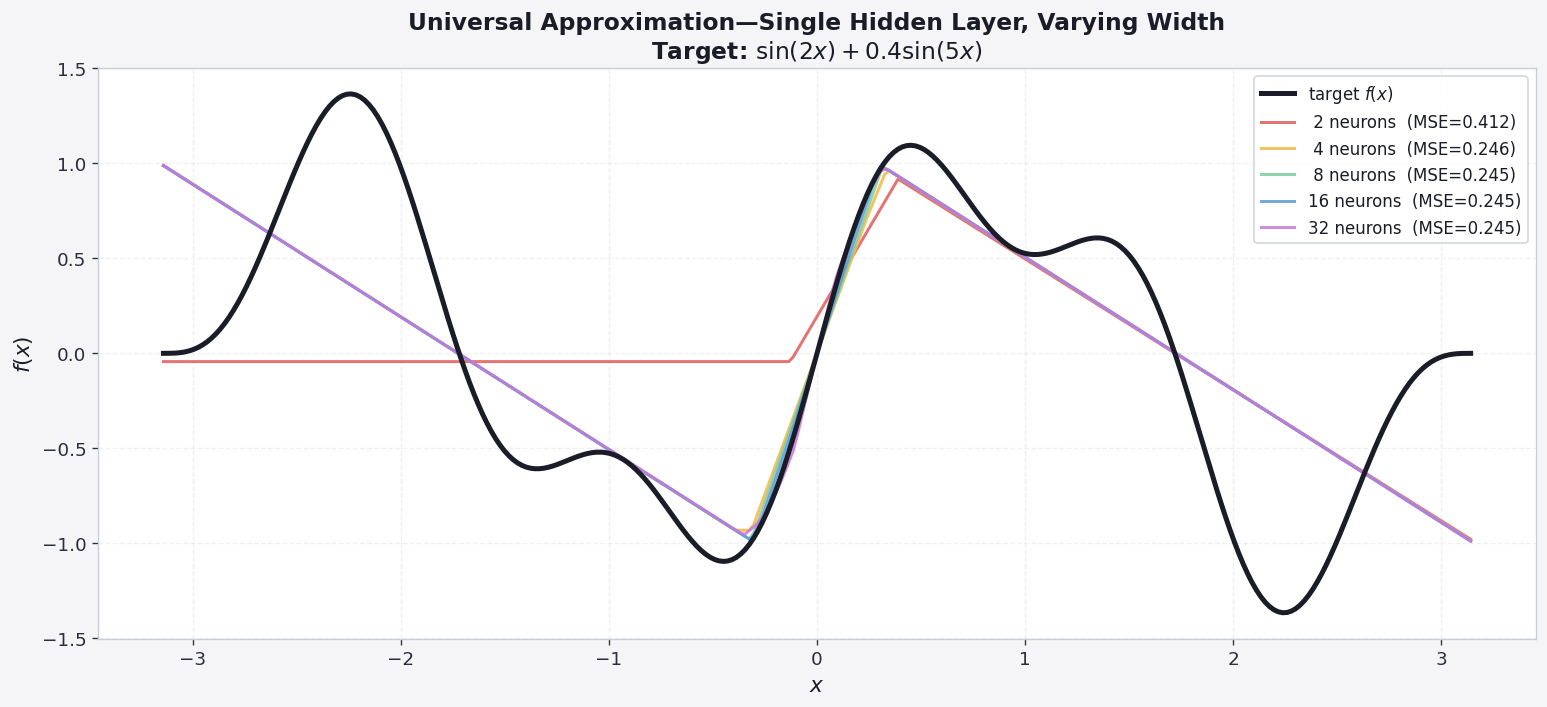

In [8]:
def train_1d_net(n_hidden, x, y, n_epochs=10000, lr=0.015, seed=0):
    rng = np.random.default_rng(seed)
    W1 = rng.normal(0, np.sqrt(2), (n_hidden, 1))
    b1 = np.zeros((n_hidden, 1))
    W2 = rng.normal(0, np.sqrt(2/n_hidden), (1, n_hidden))
    b2 = np.zeros((1, 1))
    X  = x.reshape(1,-1); Y = y.reshape(1,-1)
    for _ in range(n_epochs):
        Z1 = W1 @ X + b1;  A1 = np.maximum(0, Z1)
        A2 = W2 @ A1 + b2                              # linear output (regression)
        dZ2 = (A2 - Y) / X.shape[1]
        W2 -= lr * (dZ2 @ A1.T);  b2 -= lr * np.sum(dZ2, axis=1, keepdims=True)
        dZ1 = (W2.T @ dZ2) * (Z1 > 0)
        W1 -= lr * (dZ1 @ X.T);  b1 -= lr * np.sum(dZ1, axis=1, keepdims=True)
    def predict(xp):
        A1 = np.maximum(0, W1 @ xp.reshape(1,-1) + b1)
        return (W2 @ A1 + b2).flatten()
    return predict

x1d = np.linspace(-np.pi, np.pi, 300)
y1d = np.sin(2*x1d) + 0.4*np.sin(5*x1d)

neuron_counts = [2, 4, 8, 16, 32]
pal = [C1, CB, CM, C0, CP]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(x1d, y1d, color='#1a1d27', lw=3.0, label='target $f(x)$', zorder=5)

for n, col in zip(neuron_counts, pal):
    pred  = train_1d_net(n, x1d, y1d, seed=1)
    y_hat = pred(x1d)
    mse   = float(np.mean((y_hat - y1d)**2))
    ax.plot(x1d, y_hat, color=col, lw=1.8, alpha=0.85,
            label=f'{n:2d} neurons  (MSE={mse:.3f})')

ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
ax.set_title('Universal Approximation—Single Hidden Layer, Varying Width\n'
             r'Target: $\sin(2x)+0.4\sin(5x)$', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True)
plt.tight_layout(); plt.show()


---
## ⚖️ When to Use Neural Networks

| Situation | Neural Net | Logistic Reg | SVM | Tree / Forest |
|---|---|---|---|---|
| Large dataset ($m > 10^4$) | ✅ excels | ✅ | ⚠️ slow | ✅ |
| Small dataset ($m < 500$) | ⚠️ overfits | ✅ | ✅ | ✅ |
| Raw images / audio / text | ✅ | ❌ | ❌ | ❌ |
| Structured / tabular data | ⚠️ | ✅ | ✅ | ✅ often best |
| Need interpretability | ❌ black box | ✅ | ⚠️ | ✅ |
| Non-linear complex patterns | ✅ | ❌ | ✅ (kernel) | ✅ |
| Multi-output | ✅ | ✅ | ⚠️ | ✅ |

---

## 🎯 Try This

1. **Depth vs width.** Train `[2,32,1]` vs `[2,8,8,8,1]` on XOR (same parameter budget). Which converges faster?
2. **Activation ablation.** Replace ReLU hidden layers with `tanh`. How do training curves change? Can you explain the difference in terms of gradient magnitude?
3. **Learning rate sensitivity.** Try `lr` in `{0.001, 0.01, 0.1, 1.0}`. Plot loss curves and identify where optimisation diverges.
4. **Deeper universal approximation.** Repeat the 1D experiment with a `[1,8,8,1]` network. Can two layers of 8 neurons outperform one layer of 32?
5. **Gradient checking.** Verify backprop numerically: $\partial L/\partial w \approx [L(w+\varepsilon)-L(w-\varepsilon)]/(2\varepsilon)$ for small $\varepsilon = 10^{-5}$.

---
## Summary

| Concept | Formula / Rule | Key Insight |
|---|---|---|
| Forward pass | $\mathbf{a}^{(\ell)} = \sigma(W^{(\ell)}\mathbf{a}^{(\ell-1)}+\mathbf{b}^{(\ell)})$ | Linear then non-linear, layer by layer |
| Default activation | ReLU $= \max(0,z)$ | Gradient non-zero for $z>0$; fast; sparse |
| Output layer | Sigmoid (binary) / softmax (multi-class) | Matches the likelihood model |
| Loss | BCE $= -\bar{y}\log\hat{y}-(1-\bar{y})\log(1-\hat{y})$ | Derived from maximum likelihood |
| Backprop error | $\boldsymbol{\delta}^{(\ell)}=(W^{(\ell+1)})^\top\boldsymbol{\delta}^{(\ell+1)}\odot\sigma'(z^{(\ell)})$ | Chain rule layer by layer |
| Output gradient | $\boldsymbol{\delta}^{(L)} = \hat{\mathbf{y}}-\mathbf{y}$ | BCE + sigmoid cancellation |
| Weight update | $W^{(\ell)} \leftarrow W^{(\ell)} - \alpha\,\delta^{(\ell)}(a^{(\ell-1)})^\top/m$ | Standard gradient descent |
| XOR | Solved exactly by 2-layer non-linear net | No linear model can do it |
| Universal approx. | Width $\to\infty$, single layer $\approx$ any $f$ | Depth buys sample efficiency |

**Bottom line:** Neural networks are differentiable function approximators. Non-linearity is the source of their expressive power; backpropagation is the efficient algorithm that makes training tractable.